# Lab 5

> The toy task and the qualitative attention-vs-convolution result below are adapted
> from François Fleuret's *Deep Learning* course, University of Geneva
> (`fleuret.org/dlc`, §13.2 "Attention Mechanisms") -- licensed CC BY-NC-SA 4.0:
> non-commercial academic teaching use is explicitly permitted by the author, but any
> reuse must be attributed and shared under the same license. The dataset generator,
> model code, and training loop below are a fresh implementation for this course, not
> copied from Fleuret's own (slides-only, unpublished) code.

This lab is about attention (Session 7): why a purely local operation like convolution
cannot solve certain sequence tasks, and how self-attention fixes that -- and where
self-attention's own blind spot then shows up.

> **Instructor timing (2h session).** ~10 min: intro (this page) and the toy-task setup
> below (already filled in for you). ~25 min: Exercise 1 -- build and train a `Conv1d`
> baseline, watch it plateau. ~50 min: Exercise 2 -- implement a self-attention layer
> from scratch, swap it into the same stack, watch the same loss go far lower,
> visualize what it learned to attend to, and test whether the $1/\sqrt{d_k}$ scaling
> matters here. ~25 min: Exercise 3 -- a harder version of the
> task exposes self-attention's permutation-invariance as a weakness; a positional
> encoding (the same sinusoidal formula from the Encoder section) fixes it. ~10 min
> buffer.

## Setup

These labs are designed to run on [Google Colab](https://colab.research.google.com/) -
no local Python install needed. Open this notebook via Colab's GitHub loader
(`colab.research.google.com/github/KarikS/lecture_advanced_ai_ml/blob/main/<path-to-this-notebook>`)
or File > Open notebook > GitHub tab, repo `KarikS/lecture_advanced_ai_ml`, then run
the cell below once per session. Running the notebook locally instead (e.g. via the
`exercises/python/` venv described in that folder's README) works unchanged - this lab
needs no external dataset, so the cell below is a no-op either way; it's kept for
consistency with the other labs.

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    import os
    if not os.path.exists('lecture_advanced_ai_ml'):
        !git clone https://github.com/KarikS/lecture_advanced_ai_ml.git

## Imports

In [2]:
import random

import matplotlib.pyplot as plt
import torch
from matplotlib_inline.backend_inline import set_matplotlib_formats
from torch import nn, Tensor

set_matplotlib_formats('png', 'pdf')

## The Toy Task

Each sequence has length 100 and contains four pulses at random, non-overlapping
positions: two triangular and two rectangular, each with a random height. The task is
to replace every pulse's height with the *average* height within its shape pair - both
triangles get the mean of the two triangle heights, both rectangles get the mean of the
two rectangle heights.

This requires moving information between positions that can be arbitrarily far apart in
the sequence - exactly the kind of long-range, content-based dependency a fixed local
receptive field (a convolution's kernel) cannot express, no matter how many layers you
stack.

The generator below also returns a second target (leftmost/rightmost pairing instead of
same-shape pairing) that Exercise 3 uses - ignore it for now.

In [3]:
def draw_pulse(x: Tensor, start: int, end: int, height: float, is_triangle: bool) -> None:
    if is_triangle:
        mid = (start + end) / 2
        half_width = (end - start) / 2
        for t in range(start, end):
            x[t] = height * (1 - abs((t - mid) / half_width))
    else:
        x[start:end] = height


def generate_pulses(
    batch_size: int, seq_len: int = 100, min_width: int = 8, max_width: int = 16,
    min_height: float = 1.0, max_height: float = 25.0, margin: int = 2,
):
    """Returns (input, same_shape_target, left_right_target), each (batch_size, seq_len)."""
    inputs = torch.zeros(batch_size, seq_len)
    same_shape_targets = torch.zeros(batch_size, seq_len)
    left_right_targets = torch.zeros(batch_size, seq_len)

    for b in range(batch_size):
        # Sample 4 non-overlapping [start, end) intervals.
        intervals = []
        while len(intervals) < 4:
            width = random.randint(min_width, max_width)
            start = random.randint(margin, seq_len - width - margin)
            end = start + width
            if all(end + margin <= s or start >= e + margin for s, e in intervals):
                intervals.append((start, end))
        intervals.sort()  # left to right

        is_triangle = [True, True, False, False]
        random.shuffle(is_triangle)
        heights = [random.uniform(min_height, max_height) for _ in range(4)]

        for k, (start, end) in enumerate(intervals):
            draw_pulse(inputs[b], start, end, heights[k], is_triangle[k])

        tri_idx = [k for k in range(4) if is_triangle[k]]
        rect_idx = [k for k in range(4) if not is_triangle[k]]
        tri_mean = (heights[tri_idx[0]] + heights[tri_idx[1]]) / 2
        rect_mean = (heights[rect_idx[0]] + heights[rect_idx[1]]) / 2
        left_mean = (heights[0] + heights[1]) / 2
        right_mean = (heights[2] + heights[3]) / 2

        for k, (start, end) in enumerate(intervals):
            same_shape_h = tri_mean if is_triangle[k] else rect_mean
            draw_pulse(same_shape_targets[b], start, end, same_shape_h, is_triangle[k])
            left_right_h = left_mean if k < 2 else right_mean
            draw_pulse(left_right_targets[b], start, end, left_right_h, is_triangle[k])

    return inputs, same_shape_targets, left_right_targets

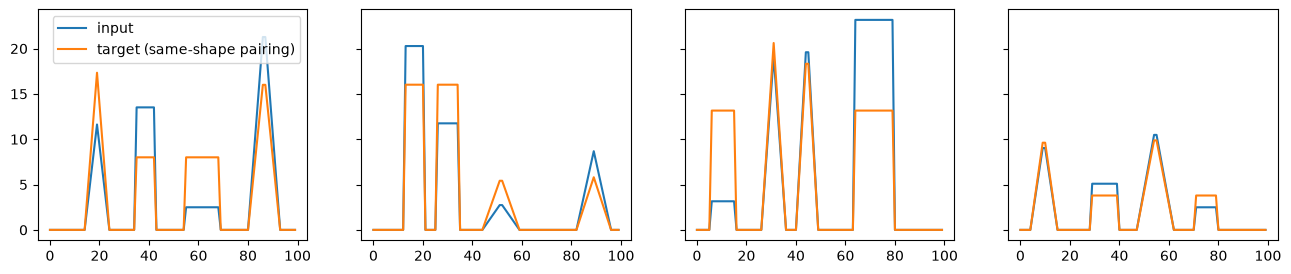

In [4]:
torch.manual_seed(0)
random.seed(0)

x_demo, y_demo, _ = generate_pulses(4)

fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
for i, ax in enumerate(axes):
    ax.plot(x_demo[i], label='input')
    ax.plot(y_demo[i], label='target (same-shape pairing)')
axes[0].legend()
plt.show()

## Exercise 1

First, a baseline with no attention at all: four `Conv1d` layers (kernel size 5, with
padding so the sequence length is preserved), the same recipe you used for images in
Lab 3, just in 1D.

In [5]:
def make_baseline_model() -> nn.Module:
    return nn.Sequential(
        nn.Conv1d(1, 64, kernel_size=5, padding=2),
        nn.ReLU(),
# TODO: Add three more convolutions (four in total), all with kernel size 5,
# 64 hidden channels and a ReLU between layers. Choose the padding so the
# sequence length stays 100. The last layer produces the 1-channel output
# and gets no activation.
    )

A `Conv1d` with `kernel_size=5` only ever looks 2 positions to either side; stacking
three of them gives a receptive field of at most 13 positions - far smaller than the
distance that can separate two pulses of the same shape in a length-100 sequence. This
model architecturally *cannot* solve the task correctly; the point of running it anyway
is to see what "failing" looks like in the loss curve, before Exercise 2 fixes it.

Training: MSE loss, Adam, standardize the input by its own mean/std first (the pulses'
raw heights are otherwise on an arbitrary scale for the optimizer).

In [6]:
def train_model(model: nn.Module, target: str = 'same', n_samples: int = 5000,
                 batch_size: int = 100, epochs: int = 30, lr: float = 1e-3,
                 use_positional_encoding: bool = False, pe_dim: int = 8, seed: int = 1):
    torch.manual_seed(seed)
    random.seed(seed)

    x_all, y_same, y_left_right = generate_pulses(n_samples)
    y_all = y_same if target == 'same' else y_left_right
    mu, std = x_all.mean(), x_all.std()
    seq_len = x_all.shape[1]

    pe = sinusoidal_positional_encoding(seq_len, pe_dim) if use_positional_encoding else None

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse_loss = nn.MSELoss()
    losses = []

    for _ in range(epochs):
        permutation = torch.randperm(n_samples)
        total_loss = 0.0

        for i in range(0, n_samples, batch_size):
            idx = permutation[i:i + batch_size]
            x_batch = (x_all[idx].unsqueeze(1) - mu) / std
            # Ignore this until Exercise 3 - it's a no-op until then. It appends the
            # positional encoding to every sequence as extra input channels.
            if use_positional_encoding:
                x_batch = torch.cat([x_batch, pe.unsqueeze(0).expand(x_batch.size(0), -1, -1)], dim=1)
            y_batch = y_all[idx].unsqueeze(1)

# TODO: Forward pass, compute the loss, backpropagate, and step the optimizer.

            total_loss += float(loss) * x_batch.size(0)

        losses.append(total_loss / n_samples)

    return losses

In [7]:
torch.manual_seed(0)
baseline_model = make_baseline_model()
baseline_losses = train_model(baseline_model, target='same')

plt.plot(baseline_losses)
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.title('Baseline (Conv1d only)')
plt.show()
print(f'Final loss: {baseline_losses[-1]:.3f}')

The loss should plateau early at a fairly high value and stay there - the model has run
out of ways to reduce it, because it structurally cannot look far enough to find each
pulse's pair partner.

## Exercise 2

Now implement a self-attention layer from scratch: project the input to queries, keys,
and values with $1\times 1$ convolutions (a $1\times 1$ conv is just a per-position
linear layer), then compute $\mathrm{softmax}(QK^\top)V$ - the same recipe from the
Encoder section, single-head, without the $1/\sqrt{d_k}$ scaling for now (the extension
at the end of this exercise comes back to it).

In [8]:
class SelfAttentionLayer(nn.Module):
    def __init__(self, in_dim: int, out_dim: int, key_dim: int):
        super().__init__()
        self.conv_Q = nn.Conv1d(in_dim, key_dim, kernel_size=1, bias=False)
        self.conv_K = nn.Conv1d(in_dim, key_dim, kernel_size=1, bias=False)
        self.conv_V = nn.Conv1d(in_dim, out_dim, kernel_size=1, bias=False)
        self.last_attention = None  # stashed after forward(), for visualization only

    def forward(self, x: Tensor) -> Tensor:
# TODO:
# 1. Compute Q, K, V by applying self.conv_Q / conv_K / conv_V to x.
# 2. Compute the attention matrix A = softmax(Q^T K) over the key axis.
# 3. Compute the output A @ V^T (then transpose back to the (N, C, T) layout).
# Hint: x has shape (batch, channels, seq_len); Q, K, V do too.

        self.last_attention = A.detach()
        return output

Now splice it into the same four-layer stack, replacing the middle convolution:

In [9]:
def make_attention_model(in_channels: int = 1) -> nn.Module:
    return nn.Sequential(
        nn.Conv1d(in_channels, 64, kernel_size=5, padding=2),
        nn.ReLU(),
# TODO: Replace this comment with a SelfAttentionLayer(64, 64, 64) followed by a ReLU.
        nn.Conv1d(64, 64, kernel_size=5, padding=2),
        nn.ReLU(),
        nn.Conv1d(64, 1, kernel_size=5, padding=2),
    )

In [10]:
torch.manual_seed(0)
attention_model = make_attention_model()
attention_losses = train_model(attention_model, target='same')

plt.plot(baseline_losses, label='baseline (Conv1d only)')
plt.plot(attention_losses, label='with self-attention')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()
print(f'Baseline final loss: {baseline_losses[-1]:.3f}  |  Attention final loss: {attention_losses[-1]:.3f}')

Same architecture, same training budget, one convolution swapped for one attention
layer - and the loss should end up several times lower, still visibly decreasing where
the baseline had already flattened out.

Let's look at *why*, by inspecting the attention matrix the layer learned:

In [11]:
attention_layer = attention_model[2]
# Standardize with statistics of a training-sized sample, as train_model() does - not the
# 4 demo sequences' own mean/std, which would feed the model a differently scaled input.
x_reference, _, _ = generate_pulses(5000)
example_input = (x_demo.unsqueeze(1) - x_reference.mean()) / x_reference.std()

with torch.no_grad():
    attention_model(example_input)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
# TODO: For each of the 4 examples, show its attention matrix as an image on its
# own axis (ax.imshow, cmap='gray_r' makes high attention dark). The forward pass
# above stored the matrices in attention_layer.last_attention, shape (4, 100, 100).
# Label the axes: which dimension of A is the query position, which the key position?
plt.tight_layout()
plt.show()

You might expect each pulse's rows to light up at that pulse's pair partner. That is not
what this model learned. The maps are dominated by *vertical stripes*: almost every query
position - including the empty stretches between pulses - attends to the same few key
positions, and those key positions sit on or at the edges of the four pulses, wherever
they happen to be in the sequence.

A plausible reading: the attention layer gathers a summary of all four pulses (their
shapes and heights) and broadcasts it to every position. The convolutions after it then
combine that global summary with each position's own local shape to compute the output.
Either way, the key point stands: *where* the layer reads from is decided by the content
of the sequence (where the pulses are), not by fixed offsets like a convolution kernel -
which is exactly what the `Conv1d` baseline could not do.

### Extension: Does the $1/\sqrt{d_k}$ Scaling Matter Here?

Every Transformer divides the attention scores by $\sqrt{d_k}$ before the softmax:
$\mathrm{softmax}(QK^\top / \sqrt{d_k})V$. The usual argument: if the components of a
query and a key are independent with mean 0 and variance 1, their dot product has
variance $d_k$ - a standard deviation of 8 for our $d_k = 64$. Scores that spread out
push the softmax towards one-hot outputs, where its gradients are almost zero, and
dividing by $\sqrt{d_k}$ brings the variance back to 1.

Our layer skipped this. Implement the scaled version as a subclass, then check whether
the argument actually applies to our model.

In [12]:
class ScaledSelfAttentionLayer(SelfAttentionLayer):
    def forward(self, x: Tensor) -> Tensor:
# TODO: Same as SelfAttentionLayer.forward, but divide the scores Q^T K by
# sqrt(d_k) before the softmax. d_k is the number of channels of Q.

        self.last_attention = A.detach()
        return output

First, test the premise: at initialization, before any training, how spread out are the
scores, and how close is the softmax to one-hot? A useful measure for the second question
is the entropy of each attention row: $\log(100) \approx 4.61$ for a perfectly uniform
row over 100 positions, $0$ for a one-hot row.

In [13]:
torch.manual_seed(0)
fresh_model = make_attention_model()
x_init = ((x_reference[:500] - x_reference.mean()) / x_reference.std()).unsqueeze(1)

with torch.no_grad():
    h = fresh_model[1](fresh_model[0](x_init))  # input to the attention layer
    Q = fresh_model[2].conv_Q(h)
    K = fresh_model[2].conv_K(h)
    scores = Q.transpose(1, 2).matmul(K)

    for name, s in [('unscaled', scores), ('scaled', scores / Q.size(1) ** 0.5)]:
        A = s.softmax(2)
        entropy = -(A * A.clamp_min(1e-12).log()).sum(2).mean()
        print(f'{name:9s} score std: {s.std():.3f}   mean row entropy: {entropy:.2f}')

Now train the same model with the scaled layer and compare it with the unscaled one:

In [14]:
torch.manual_seed(0)
scaled_attention_model = make_attention_model()
scaled_attention_model[2] = ScaledSelfAttentionLayer(64, 64, 64)
scaled_attention_losses = train_model(scaled_attention_model, target='same')

plt.plot(attention_losses, label='unscaled attention')
plt.plot(scaled_attention_losses, label='scaled attention')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()
print(f'Unscaled final loss: {attention_losses[-1]:.3f}  |  Scaled final loss: {scaled_attention_losses[-1]:.3f}')

**Question:** Scaling is standard in every Transformer. Why doesn't it help here?

## Exercise 3

The attention layer above is *invariant* to a permutation of the keys and values: shuffle
the key/value positions (together), and the output at each query position stays the
same. Shuffle the whole input instead, and the outputs are simply shuffled the same way -
the layer itself never sees where a position is. That is
exactly why it could solve the same-shape task regardless of where the shapes ended up -
but it also means the layer has no way to know *where* in the sequence something is,
only *what* is nearby in content.

To see this cut the other way, retrain the same architecture on the `'left_right'`
target instead: now the two *leftmost* shapes must be paired with each other, and the two
*rightmost* shapes with each other - position, not shape identity, determines pairing.

In [15]:
torch.manual_seed(0)
attention_model_lr = make_attention_model()
attention_lr_losses = train_model(attention_model_lr, target='left_right')

plt.plot(attention_losses, label='attention, same-shape task')
plt.plot(attention_lr_losses, label='attention, leftmost/rightmost task')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()
print(f'Final loss on leftmost/rightmost task: {attention_lr_losses[-1]:.3f}')

The loss should plateau much higher than it did on the same-shape task - the model is
now missing information it structurally cannot recover on its own: position.

The fix is the same one the Encoder section introduced: add a **positional encoding** to
the input, so position becomes part of the content every layer can see. Implement the
sinusoidal encoding from that section,
$$
PE_{t,2i} = \sin\!\left(\frac{t}{10000^{2i/d}}\right), \qquad
PE_{t,2i+1} = \cos\!\left(\frac{t}{10000^{2i/d}}\right),
$$
as a $(d, T)$ tensor ($d$ = `dim`, $T$ = `seq_len`) that gets concatenated to the input as
extra channels.

In [16]:
def sinusoidal_positional_encoding(seq_len: int, dim: int) -> Tensor:
# TODO: Build the (dim, seq_len) positional encoding tensor using the formula above.
    return pe

In [17]:
PE_DIM = 8

torch.manual_seed(0)
attention_model_pe = make_attention_model(in_channels=1 + PE_DIM)
attention_pe_losses = train_model(
    attention_model_pe, target='left_right', use_positional_encoding=True, pe_dim=PE_DIM,
)

plt.plot(attention_lr_losses, label='leftmost/rightmost, no positional encoding')
plt.plot(attention_pe_losses, label='leftmost/rightmost, with positional encoding')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()
print(f'Final loss with positional encoding: {attention_pe_losses[-1]:.3f}')

Adding position back in as explicit information should close most of the gap: the model
can now tell *where* a shape is, not just *what* it looks like, which is exactly what
this task needs and the same-shape task didn't.

### Conclusion

Here's what you should take away from this lab:

 - A stack of convolutions is fundamentally local: no matter how many layers you add, a
`Conv1d`'s receptive field grows only linearly, and it still cannot cheaply route
information between two arbitrary, far-apart positions. Self-attention can, in a single
layer, because every query is compared against every key directly (Exercise 1 vs. 2).
 - Self-attention's content-based routing comes with a specific blind spot: it is
invariant to the order of its input. On a task where identity alone determines the
correct pairing (Exercise 2), that is exactly the property you want. On a task where
*position* also matters (Exercise 3), the same property becomes a failure mode.
 - Positional encoding is not a minor implementation detail bolted onto the Transformer -
it is the specific fix for a specific, demonstrable gap in what self-attention can
represent on its own.